# 01. Learned reduced-order modeling of a single scattering wavefunction

This notebook develops a learned reduced-order model (LROM) for the
$\ell=0$ neutron-scattering wavefunction of $^{40}\mathrm{Ca}$ at
$E_{\mathrm{lab}}=14.1$ MeV. Two optical-parameter studies are used:

1. variation of the real Woods–Saxon depth $V_v$;
2. simultaneous variation of $(V_v,R_v,a_v)$.

The full-order wavefunctions are generated by the independent solver in
`lrom.fom`. The centered reduced basis and learned implicit equation are
implemented in `lrom.reduced`. ROSE is used only in a separate benchmark
calculation, with its own full-order solver and Petrov–Galerkin reduced
model.

## Mathematical structure

A centered reduced representation is written as

$$
\phi(s;\boldsymbol\omega) \approx \phi_0(s)
+ \sum_{i=1}^{N_\phi} a_i(\boldsymbol\omega)\,\psi_i(s),
$$

where $\phi_0$ is the wavefunction at the central optical potential and
the basis vectors $\psi_i$ are obtained from an SVD of the centered FOM
snapshots. Instead of projecting the Schrödinger equation online, LROM
learns the implicit reduced system

$$
\left[I+\sum_{j=1}^{N_p}p_j(\boldsymbol\omega)M_j\right]a
=\sum_{j=1}^{N_p}p_j(\boldsymbol\omega)b_j.
$$

Here $s=kr$ and the scaled Schrödinger operator contains
$\widetilde U(s)=V(s/k)/E_{\rm cm}$. This common dimensionless mesh gives
every snapshot the same free-wave frequency. The features $p_j$ are
normalized values of $\widetilde U$ at coordinates selected from a
potential SVD. Once trained, inference requires only a small
$N_\phi\times N_\phi$ linear solve.

In [1]:
import os, sys, time
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.matplotlib-cache'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from lrom import (BasisConfig, MaxVol, ScatteringLROM, ScatteringProblem, get_runtime)
from lrom.physics import real_woods_saxon, two_body_kinematics
from lrom.reduced import latin_hypercube
from lrom.diagnostics import absolute_l2, relative_l2

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"LS": "#2457E6", "LROM": "#E6AB02", "ROSE": "#EF4423"}
PARAMETER_CMAP = LinearSegmentedColormap.from_list(
    "parameter", ["#2446A8", "#7776D4", "#C66EC5", "#F15A9D"]
)
ERROR_FLOOR = 1.0e-12
SEED = 1204
BASIS_SIZE = 4

reduced_mass, com_energy, relativistic_k = two_body_kinematics(
    40, 20, 1, 0, 14.1,
    target_binding_energy=342.052184,  # AME2020 binding energy for 40Ca
)
problem = ScatteringProblem(
    potential="real_woods_saxon", target_a=40, target_z=20,
    lab_energy=14.1, l_max=0, mesh_points=800,
    target_binding_energy=342.052184,
)
system = problem.system()
s_mesh = system.s_mesh
radius = system.radius
radial_error_mask = radius >= 0.5
omega0 = np.array([46.7238, 4.0538, 0.6718])  # Vv [MeV], Rv [fm], av [fm]

def samples_from_rows(rows):
    '''Convert ordered (Vv, Rv, av) rows to the package's named inputs.'''
    return [
        {"Vv": float(row[0]), "Rv": float(row[1]), "av": float(row[2]),
         "E": 14.1, "A": 40, "Z": 20}
        for row in np.asarray(rows)
    ]

reference_data = problem.generate_training_data([problem.reference_sample])
phi0 = reference_data.reference_wavefunctions[(0, 0.0)]
potential0 = real_woods_saxon(radius, omega0)
pd.Series({
    "target": "40Ca", "projectile": "neutron",
    "E_lab [MeV]": system.lab_energy,
    "E_cm [MeV]": system.com_energy,
    "effective reduced mass [MeV]": system.reduced_mass,
    "wave number [fm^-1]": system.wave_number,
    "relativistic momentum [fm^-1]": relativistic_k,
    "scaled mesh points": len(s_mesh), "s_max": s_mesh[-1],
    "matching s": system.matching_s, "equivalent r_max [fm]": radius[-1],
}, name="calculation")

BACKEND = os.getenv("LROM_BACKEND", "cpu")
PRECISION = os.getenv("LROM_PRECISION", "double")
runtime = get_runtime(BACKEND, PRECISION)
print(f"online runtime: {runtime.name} on {runtime.device} ({runtime.precision})")


online runtime: numpy-cpu on CPU (double)


# 1. Variation of the real depth $V_v$

The training set spans $0.90V_{v,0}\leq V_v\leq1.10V_{v,0}$.
Testing extends to $0.65V_{v,0}\leq V_v\leq1.35V_{v,0}$ so that the
same calculation displays interpolation and extrapolation. The radius
and diffuseness remain fixed at their central values.

In [2]:
train_vv = np.tile(omega0, (35, 1))
test_vv = np.tile(omega0, (41, 1))
train_vv[:, 0] = np.linspace(.90 * omega0[0], 1.10 * omega0[0], len(train_vv))
test_vv[:, 0] = np.linspace(.65 * omega0[0], 1.35 * omega0[0], len(test_vv))

train_samples_vv = samples_from_rows(train_vv)
test_samples_vv = samples_from_rows(test_vv)
noncentral_train_vv = ~np.isclose(train_vv[:, 0], omega0[0])
noncentral_test_vv = ~np.isclose(test_vv[:, 0], omega0[0])
training_data_vv = problem.generate_training_data(train_samples_vv)
testing_data_vv = problem.generate_training_data(test_samples_vv)
train_phi_vv = training_data_vv.wavefunctions[(0, 0.0)]
test_phi_vv = testing_data_vv.wavefunctions[(0, 0.0)]
train_potential_vv = training_data_vv.potentials[(0, 0.0)]
test_potential_vv = testing_data_vv.potentials[(0, 0.0)]
train_physical_potential_vv = np.asarray([
    real_woods_saxon(radius, row) for row in train_vv
])

pd.DataFrame({
    "set": ["training", "testing"],
    "cases": [len(train_vv), len(test_vv)],
    "Vv minimum [MeV]": [train_vv[:,0].min(), test_vv[:,0].min()],
    "Vv maximum [MeV]": [train_vv[:,0].max(), test_vv[:,0].max()],
})

,set,cases,Vv minimum [MeV],Vv maximum [MeV]
0,training,35,42.05142,51.39618
1,testing,41,30.37047,63.07713


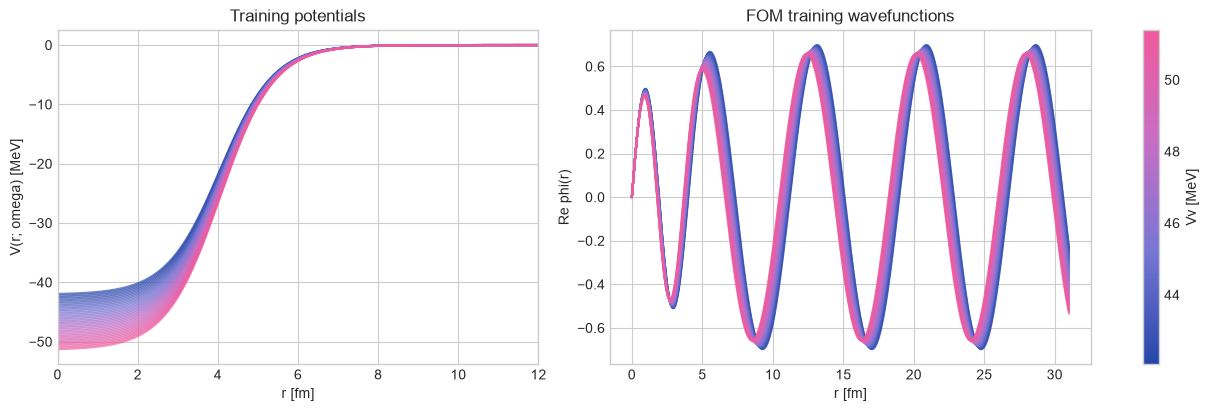

In [3]:
norm = plt.Normalize(train_vv[:, 0].min(), train_vv[:, 0].max())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for vv, optical, wave in zip(train_vv[:, 0], train_physical_potential_vv, train_phi_vv):
    color = PARAMETER_CMAP(norm(vv))
    axes[0].plot(radius, optical.real, color=color, alpha=.65)
    axes[1].plot(radius, wave.real, color=color, alpha=.65)
axes[0].set(xlim=(0, 12), xlabel="r [fm]", ylabel="V(r; omega) [MeV]", title="Training potentials")
axes[1].set(xlabel="r [fm]", ylabel="Re phi(r)", title="FOM training wavefunctions")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=PARAMETER_CMAP), ax=axes, label="Vv [MeV]")
plt.show()

## 1.1 Reduced basis and learned coordinate map

Four centered SVD modes are retained. With one varied parameter, one
scaled-potential feature is sufficient for the implicit reduced equation. The
exact least-squares (LS) projection is also calculated. LS sees the FOM
test wavefunction and therefore measures the best accuracy available in
the fixed basis; it is an oracle diagnostic, not an emulator.

In [4]:
emulator_vv = ScatteringLROM(
    problem, BasisConfig(size=BASIS_SIZE), MaxVol(count=1),
).train(training_data_vv)
model_vv = emulator_vv.channel_models[(0, 0.0)].learned
predictions_train_vv = [emulator_vv.predict(sample) for sample in train_samples_vv]
predictions_test_vv = [emulator_vv.predict(sample) for sample in test_samples_vv]
lrom_train_vv = np.asarray([p.wavefunction((0, 0.0)) for p in predictions_train_vv])
lrom_test_vv = np.asarray([p.wavefunction((0, 0.0)) for p in predictions_test_vv])
lrom_train_coordinates_vv = np.asarray([p.coordinates((0, 0.0)) for p in predictions_train_vv])
lrom_test_coordinates_vv = np.asarray([p.coordinates((0, 0.0)) for p in predictions_test_vv])

ls_train_coordinates_vv = model_vv.basis.project(train_phi_vv)
ls_test_coordinates_vv = model_vv.basis.project(test_phi_vv)
ls_train_vv = model_vv.basis.reconstruct(ls_train_coordinates_vv)
ls_test_vv = model_vv.basis.reconstruct(ls_test_coordinates_vv)

pd.Series({
    "basis size": BASIS_SIZE,
    "predictor count": 1,
    "selected s": model_vv.selected_coordinates[0],
    "selected radius [fm]": model_vv.selected_coordinates[0] / system.wave_number,
    "implicit-fit residual MSE": model_vv.fit_residual,
}, name="Vv-only LROM")

basis size                   4.000000e+00
predictor count              1.000000e+00
selected s                   1.258210e-01
selected radius [fm]         1.552892e-01
implicit-fit residual MSE    1.139689e-15
Name: Vv-only LROM, dtype: float64

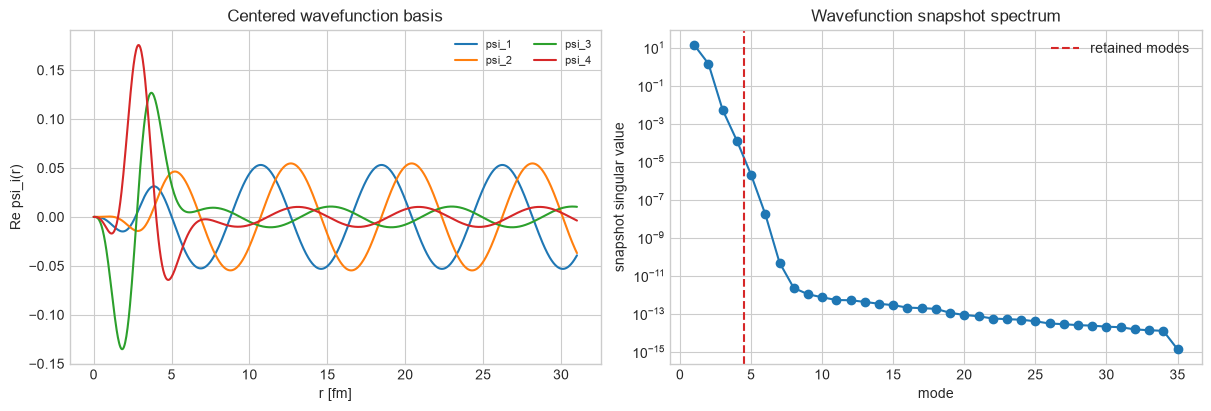

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for index in range(BASIS_SIZE):
    axes[0].plot(radius, model_vv.basis.vectors[:, index].real, label=f"psi_{index+1}")
axes[0].set(xlabel="r [fm]", ylabel="Re psi_i(r)", title="Centered wavefunction basis")
axes[0].legend(ncol=2, fontsize=8)
singular = model_vv.basis.singular_values
axes[1].semilogy(np.arange(1, len(singular)+1), singular, "o-")
axes[1].axvline(BASIS_SIZE + .5, color="C3", ls="--", label="retained modes")
axes[1].set(xlabel="mode", ylabel="snapshot singular value", title="Wavefunction snapshot spectrum")
axes[1].legend()
plt.show()

## 1.2 Independent ROSE benchmark

ROSE constructs its own Runge–Kutta wavefunctions, free-reference basis,
empirical interaction representation, and Petrov–Galerkin emulator on
the same optical-parameter rows. ROSE data are not used by the LROM
training pipeline.

In [6]:
import rose  # explicit optional dependency for this benchmark section
from benchmarks.rose import wavefunction_benchmark

rose_vv = wavefunction_benchmark(
    radius, train_vv, test_vv,
    basis_size=BASIS_SIZE, eim_size=8,
)
rose_train_error_vv = relative_l2(rose_vv.training_prediction, rose_vv.training_exact)
rose_test_error_vv = relative_l2(rose_vv.testing_prediction, rose_vv.testing_exact)
print("ROSE benchmark complete; its FOM and basis remain independent of LROM.")

ROSE benchmark complete; its FOM and basis remain independent of LROM.


### Direct FOM comparison

The two full-order solvers use the same optical potential, center-of-mass
energy, effective reduced mass, scaled-coordinate mesh, and positive-slope
shooting convention. Their remaining difference is primarily numerical:
LROM uses Numerov while ROSE uses adaptive Runge–Kutta. This comparison is
performed before either reduced model is applied.

In [7]:
fom_rose_relative_vv = relative_l2(test_phi_vv, rose_vv.testing_exact)
central_index_vv = int(np.argmin(np.abs(test_vv[:,0]-omega0[0])))
slope_numerov = (test_phi_vv[central_index_vv,1]-test_phi_vv[central_index_vv,0])/(radius[1]-radius[0])
slope_rose = (rose_vv.testing_exact[central_index_vv,1]-rose_vv.testing_exact[central_index_vv,0])/(radius[1]-radius[0])
pd.Series({
    "Numerov origin slope": slope_numerov.real,
    "ROSE origin slope": slope_rose.real,
    "central relative L2 difference": fom_rose_relative_vv[central_index_vv],
    "median relative L2 difference": np.median(fom_rose_relative_vv),
    "maximum relative L2 difference": np.max(fom_rose_relative_vv),
}, name="FOM comparison")

Numerov origin slope              0.810237
ROSE origin slope                 0.809650
central relative L2 difference    0.000724
median relative L2 difference     0.000724
maximum relative L2 difference    0.000920
Name: FOM comparison, dtype: float64

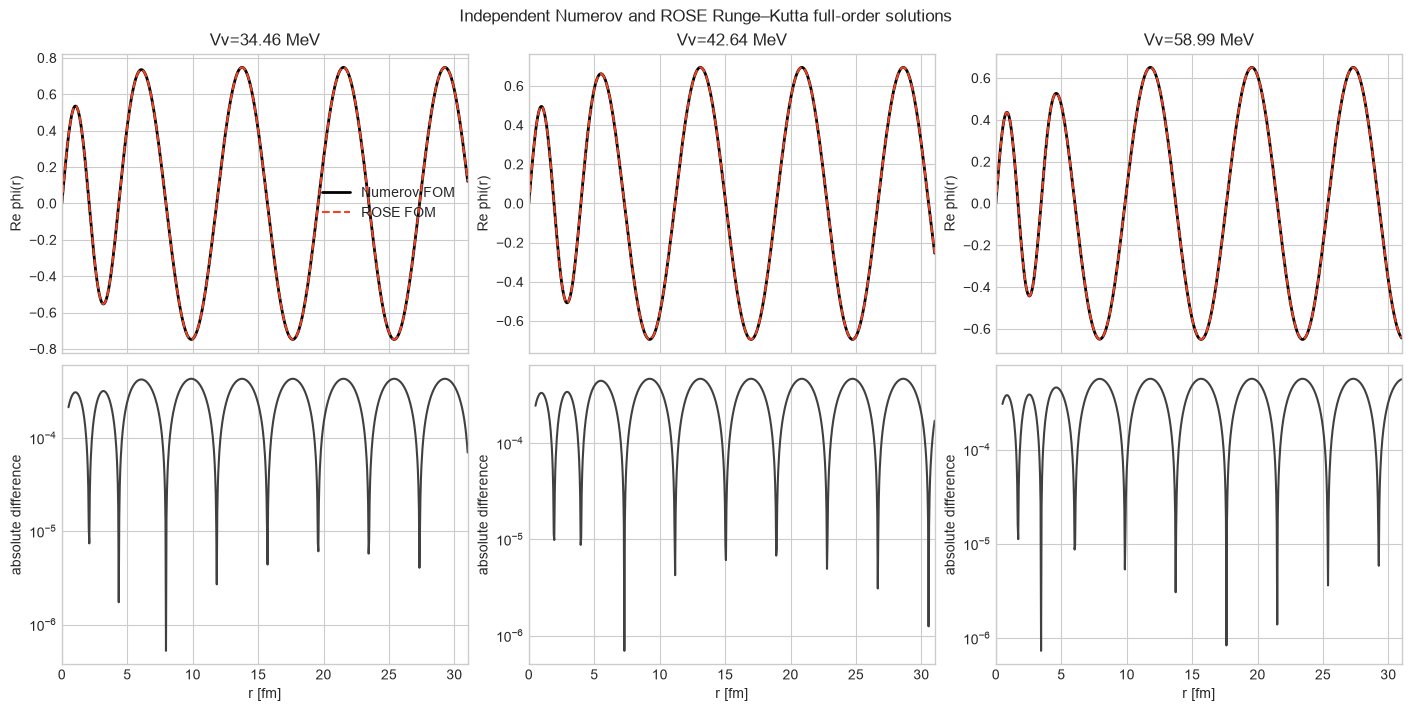

In [8]:
comparison_indices = np.array([5, 15, len(test_vv)-6])
fig, axes = plt.subplots(2, 3, figsize=(14,7), sharex="col", layout="constrained")
for column,index in enumerate(comparison_indices):
    axes[0,column].plot(radius,test_phi_vv[index].real,color="black",lw=2,label="Numerov FOM")
    axes[0,column].plot(radius,rose_vv.testing_exact[index].real,"--",color=COLORS["ROSE"],label="ROSE FOM")
    difference = np.abs(test_phi_vv[index]-rose_vv.testing_exact[index])
    axes[1,column].semilogy(radius[radial_error_mask],np.maximum(difference[radial_error_mask],ERROR_FLOOR),color="0.25")
    axes[0,column].set(title=f"Vv={test_vv[index,0]:.2f} MeV",ylabel="Re phi(r)")
    axes[1,column].set(xlabel="r [fm]",ylabel="absolute difference",xlim=(0,radius[-1]))
axes[0,0].legend()
fig.suptitle("Independent Numerov and ROSE Runge–Kutta full-order solutions")
plt.show()

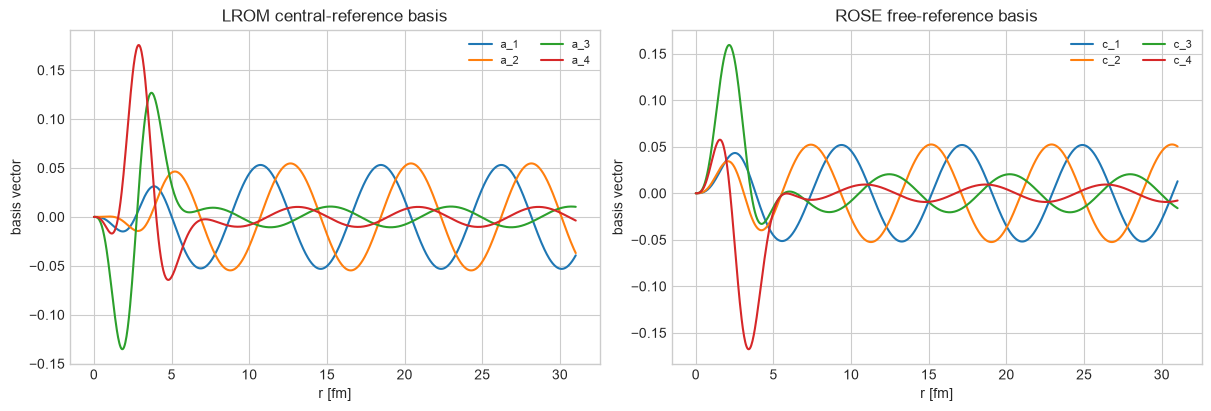

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for index in range(BASIS_SIZE):
    axes[0].plot(radius, model_vv.basis.vectors[:, index].real, label=f"a_{index+1}")
    axes[1].plot(radius, rose_vv.basis_vectors[:, index].real, label=f"c_{index+1}")
axes[0].set(xlabel="r [fm]", ylabel="basis vector", title="LROM central-reference basis")
axes[1].set(xlabel="r [fm]", ylabel="basis vector", title="ROSE free-reference basis")
for ax in axes:
    ax.legend(ncol=2, fontsize=8)
plt.show()

## 1.3 Reduced coordinates

LS and LROM coordinates use the same centered basis and can be compared
directly. ROSE coefficients belong to a different free-reference basis
and are displayed in a separate row. Their numerical values should not
be compared component by component across the two bases.

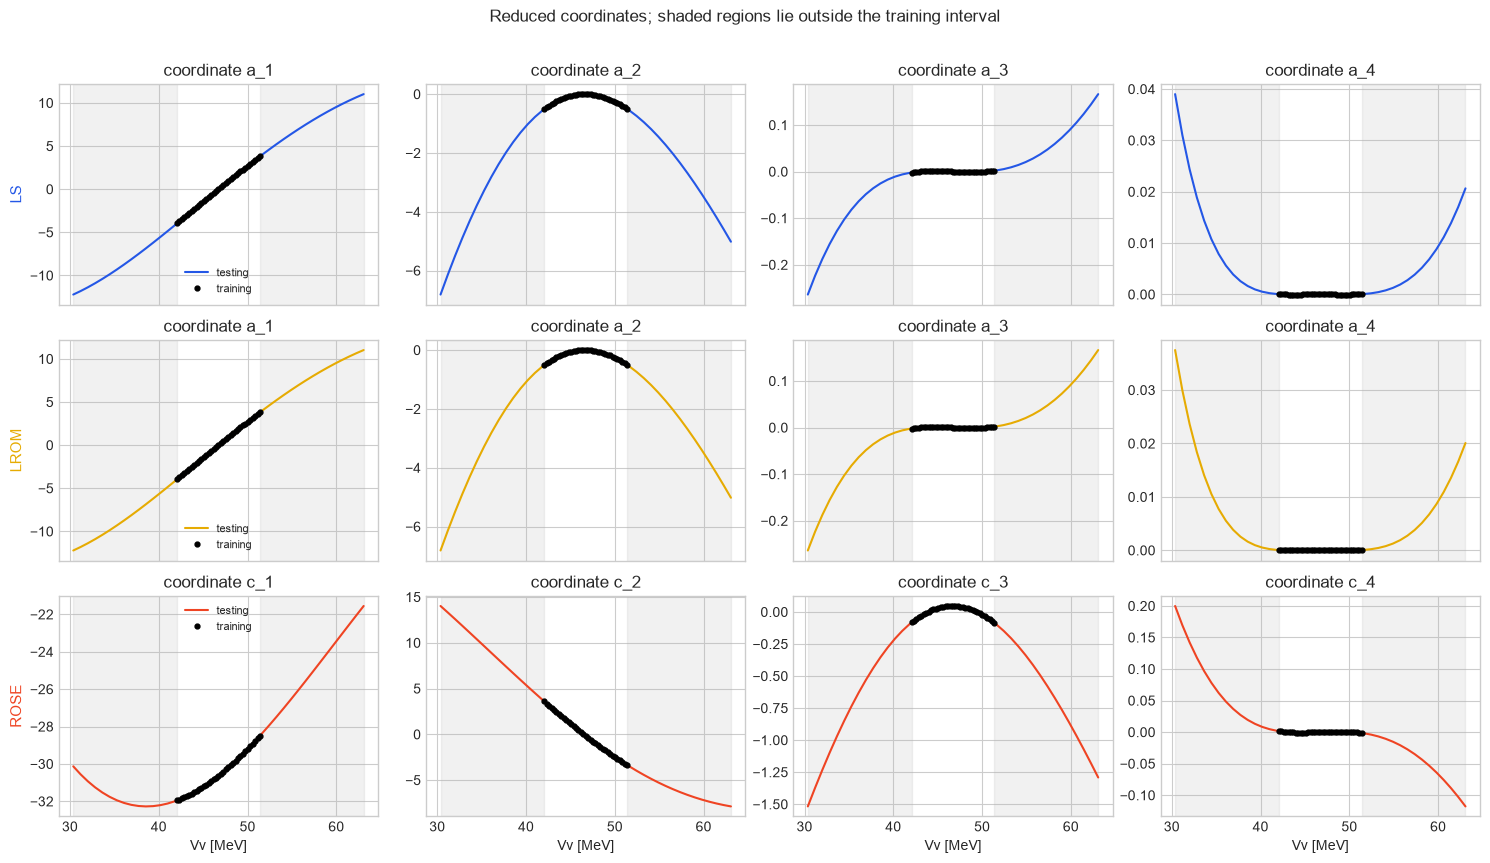

In [10]:
coordinate_rows = [
    ("LS", ls_train_coordinates_vv, ls_test_coordinates_vv, "a", COLORS["LS"]),
    ("LROM", lrom_train_coordinates_vv, lrom_test_coordinates_vv, "a", COLORS["LROM"]),
    ("ROSE", rose_vv.training_coefficients, rose_vv.testing_coefficients, "c", COLORS["ROSE"]),
]
train_min, train_max = train_vv[:,0].min(), train_vv[:,0].max()
fig, axes = plt.subplots(3, BASIS_SIZE, figsize=(15, 8.5), sharex=True)
for row_index, (name, training, testing, symbol, color) in enumerate(coordinate_rows):
    for column in range(BASIS_SIZE):
        ax = axes[row_index, column]
        ax.plot(test_vv[:,0], testing[:,column].real, color=color, label="testing")
        ax.plot(train_vv[:,0], training[:,column].real, "o", ms=3.5, color="black", label="training")
        ax.axvspan(test_vv[:,0].min(), train_min, color="0.7", alpha=.18)
        ax.axvspan(train_max, test_vv[:,0].max(), color="0.7", alpha=.18)
        ax.set_title(f"coordinate {symbol}_{column+1}")
        if column == 0:
            ax.set_ylabel(name, color=color, fontsize=11)
            ax.legend(fontsize=8)
        if row_index == 2:
            ax.set_xlabel("Vv [MeV]")
fig.suptitle("Reduced coordinates; shaded regions lie outside the training interval", y=1.01)
fig.tight_layout()
plt.show()

## 1.4 Wavefunction reconstruction and extrapolation

Three held-out cases are selected across the testing interval. LROM and
LS are compared with the independent Numerov FOM. ROSE is shown against
its own Runge–Kutta FOM in a separate figure so that solver conventions
are not mixed in the reduced-model error definition. The trivial central
solution is excluded from these examples. Radial error curves begin at
$r=0.5$ fm, where methods are no longer constrained by the common
near-origin boundary behavior; the axes retain the full 0–30 fm range
for alignment. Exact zeros are replaced by $10^{-12}$ only when needed
for logarithmic rendering.

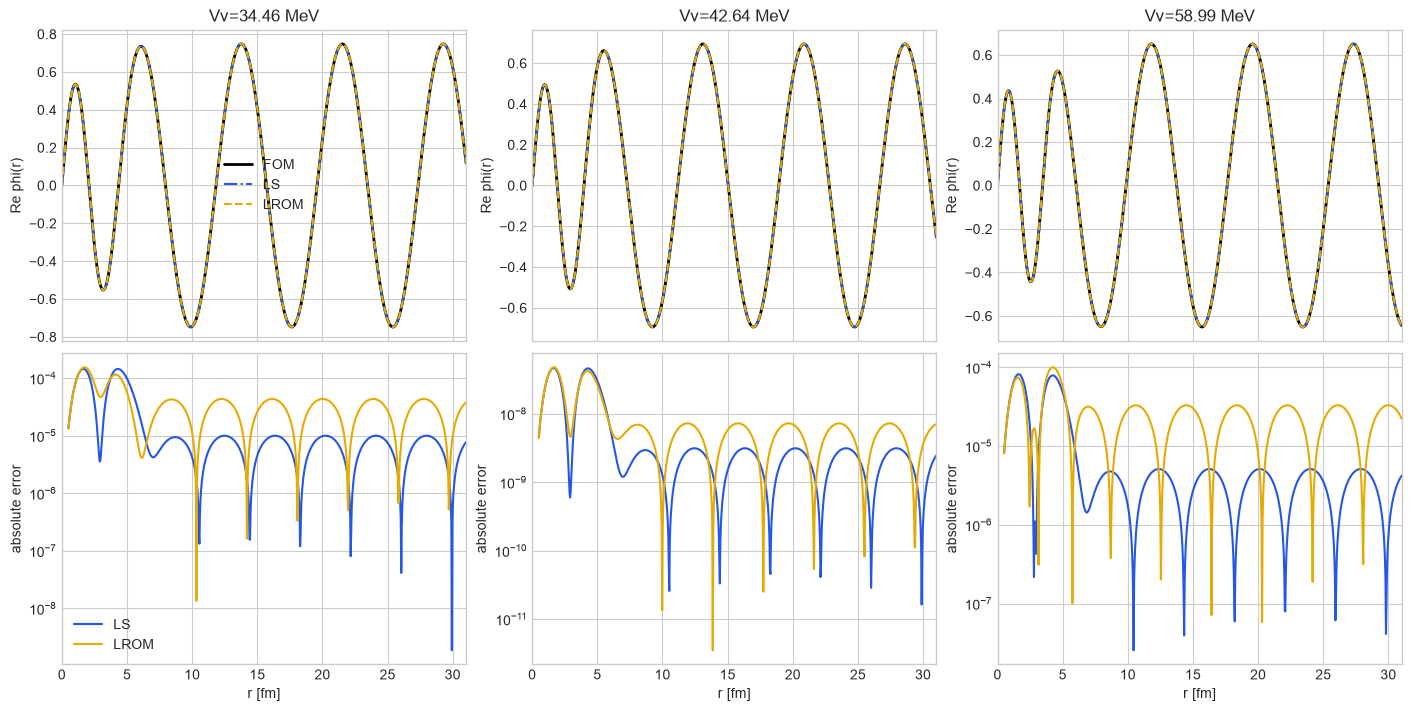

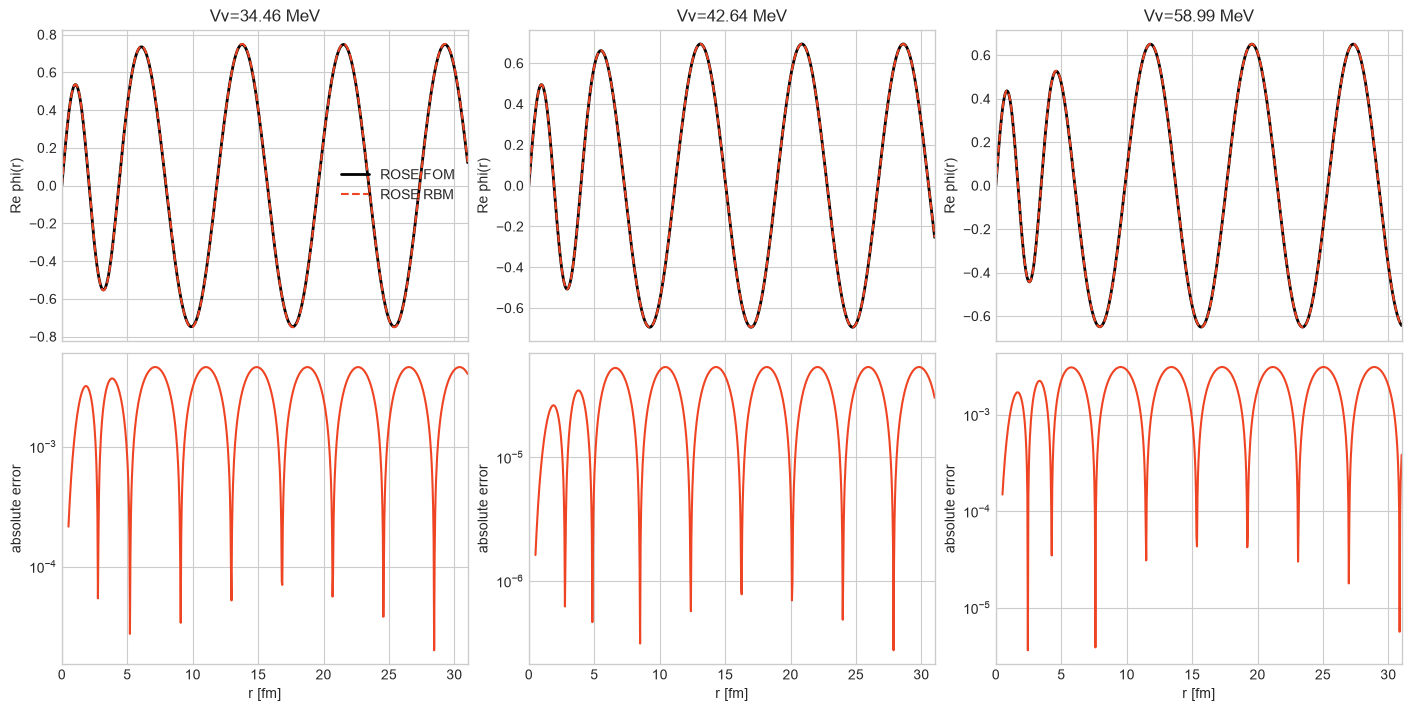

In [11]:
selected_vv = np.array([5, 15, len(test_vv)-6])
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex="col", layout="constrained")
for column, index in enumerate(selected_vv):
    axes[0,column].plot(radius, test_phi_vv[index].real, color="black", lw=2, label="FOM")
    axes[0,column].plot(radius, ls_test_vv[index].real, "-.", color=COLORS["LS"], label="LS")
    axes[0,column].plot(radius, lrom_test_vv[index].real, "--", color=COLORS["LROM"], label="LROM")
    ls_error = np.abs(ls_test_vv[index]-test_phi_vv[index])
    lrom_error = np.abs(lrom_test_vv[index]-test_phi_vv[index])
    axes[1,column].semilogy(radius[radial_error_mask], np.maximum(ls_error[radial_error_mask], ERROR_FLOOR), color=COLORS["LS"], label="LS")
    axes[1,column].semilogy(radius[radial_error_mask], np.maximum(lrom_error[radial_error_mask], ERROR_FLOOR), color=COLORS["LROM"], label="LROM")
    axes[0,column].set(title=f"Vv={test_vv[index,0]:.2f} MeV", ylabel="Re phi(r)")
    axes[1,column].set(xlabel="r [fm]", ylabel="absolute error", xlim=(0,radius[-1]))
axes[0,0].legend(); axes[1,0].legend()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex="col", layout="constrained")
for column, index in enumerate(selected_vv):
    axes[0,column].plot(radius, rose_vv.testing_exact[index].real, color="black", lw=2, label="ROSE FOM")
    axes[0,column].plot(radius, rose_vv.testing_prediction[index].real, "--", color=COLORS["ROSE"], label="ROSE RBM")
    rose_error = np.abs(rose_vv.testing_prediction[index]-rose_vv.testing_exact[index])
    axes[1,column].semilogy(radius[radial_error_mask], np.maximum(rose_error[radial_error_mask], ERROR_FLOOR), color=COLORS["ROSE"])
    axes[0,column].set(title=f"Vv={test_vv[index,0]:.2f} MeV", ylabel="Re phi(r)")
    axes[1,column].set(xlabel="r [fm]", ylabel="absolute error", xlim=(0,radius[-1]))
axes[0,0].legend()
plt.show()

In [12]:
metrics_vv = pd.DataFrame({
    "method": ["LS", "LROM", "ROSE RBM"],
    "reference": ["Numerov FOM", "Numerov FOM", "ROSE FOM"],
    "training median relative L2": [
        np.median(relative_l2(ls_train_vv, train_phi_vv)[noncentral_train_vv]),
        np.median(relative_l2(lrom_train_vv, train_phi_vv)[noncentral_train_vv]),
        np.median(rose_train_error_vv[noncentral_train_vv]),
    ],
    "testing median relative L2": [
        np.median(relative_l2(ls_test_vv, test_phi_vv)[noncentral_test_vv]),
        np.median(relative_l2(lrom_test_vv, test_phi_vv)[noncentral_test_vv]),
        np.median(rose_test_error_vv[noncentral_test_vv]),
    ],
})
metrics_vv

,method,reference,training median relative L2,testing median relative L2
0,LS,Numerov FOM,2.435013e-08,0.000009
1,LROM,Numerov FOM,2.485518e-08,0.000010
2,ROSE RBM,ROSE FOM,1.542085e-04,0.001278


### Training and testing error distributions

The table reports medians, while the split violins retain the full error
distributions. Each left half contains training cases and each right
half contains held-out testing cases. The exact central potential is
excluded from both sides because the centered representation reproduces
its reference wavefunction essentially by construction. Including it
would add a trivial near-zero error to every distribution. ROSE errors
continue to use the independent ROSE FOM as their reference.

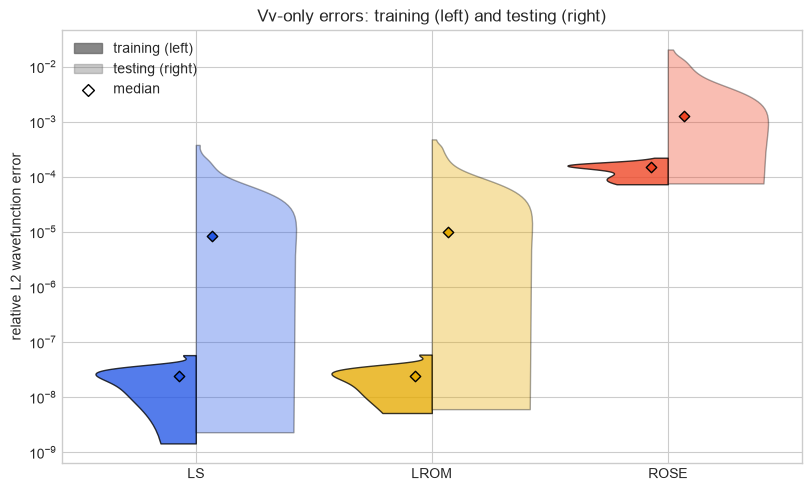

In [13]:
vv_training_errors = {
    "LS": relative_l2(ls_train_vv,train_phi_vv)[noncentral_train_vv],
    "LROM": relative_l2(lrom_train_vv,train_phi_vv)[noncentral_train_vv],
    "ROSE": rose_train_error_vv[noncentral_train_vv],
}
vv_testing_errors = {
    "LS": relative_l2(ls_test_vv,test_phi_vv)[noncentral_test_vv],
    "LROM": relative_l2(lrom_test_vv,test_phi_vv)[noncentral_test_vv],
    "ROSE": rose_test_error_vv[noncentral_test_vv],
}
methods_vv = ["LS","LROM","ROSE"]
positions_vv = np.arange(1,len(methods_vv)+1)
fig,ax=plt.subplots(figsize=(8,4.8),layout="constrained")
left=ax.violinplot(
    [vv_training_errors[name] for name in methods_vv],
    positions=positions_vv,widths=.85,showextrema=False,
)
right=ax.violinplot(
    [vv_testing_errors[name] for name in methods_vv],
    positions=positions_vv,widths=.85,showextrema=False,
)
for center,body,name in zip(positions_vv,left["bodies"],methods_vv):
    vertices=body.get_paths()[0].vertices
    vertices[:,0]=np.minimum(vertices[:,0],center)
    body.set_facecolor(COLORS[name]); body.set_edgecolor("black"); body.set_alpha(.78)
    ax.scatter(center-.07,np.median(vv_training_errors[name]),marker="D",s=28,color=COLORS[name],edgecolor="black",zorder=5)
for center,body,name in zip(positions_vv,right["bodies"],methods_vv):
    vertices=body.get_paths()[0].vertices
    vertices[:,0]=np.maximum(vertices[:,0],center)
    body.set_facecolor(COLORS[name]); body.set_edgecolor("black"); body.set_alpha(.35)
    ax.scatter(center+.07,np.median(vv_testing_errors[name]),marker="D",s=28,color=COLORS[name],edgecolor="black",zorder=5)
ax.set_xticks(positions_vv,methods_vv)
ax.set_yscale("log")
ax.set(ylabel="relative L2 wavefunction error",title="Vv-only errors: training (left) and testing (right)")
ax.fill_between([],[],color="0.4",alpha=.78,label="training (left)")
ax.fill_between([],[],color="0.4",alpha=.35,label="testing (right)")
ax.scatter([],[],marker="D",color="white",edgecolor="black",label="median")
ax.legend()
plt.show()

# 2. Simultaneous variation of $(V_v,R_v,a_v)$

The training design contains 70 Latin-hypercube points in a $\pm10\%$
box. The 81-point testing design is broader: $\pm22\%$ in depth and
$\pm20\%$ in radius and diffuseness. The increased input dimension
motivates potential-based predictors rather than a single parameter
feature.

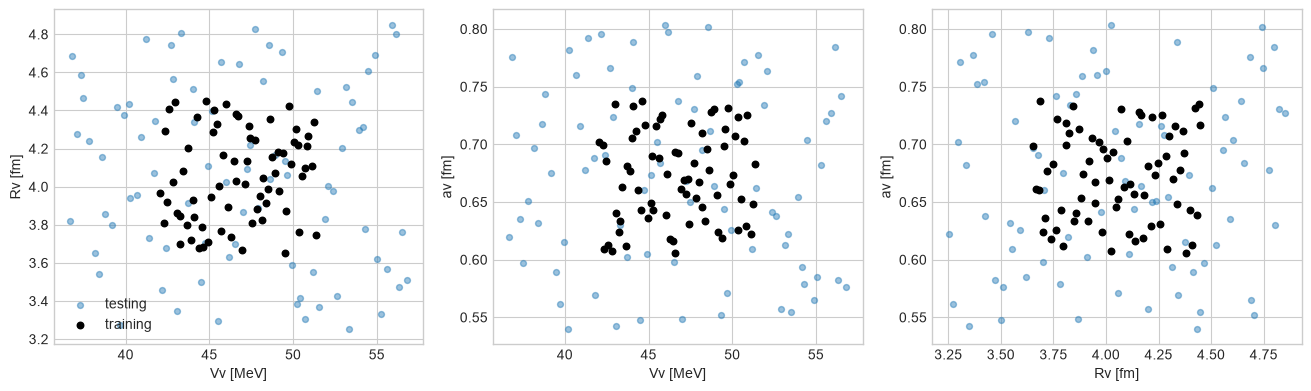

In [14]:
train_ws = latin_hypercube(.90*omega0, 1.10*omega0, 70, SEED)
test_ws = latin_hypercube(
    np.array([.78,.80,.80])*omega0,
    np.array([1.22,1.20,1.20])*omega0,
    81, SEED+1,
)
train_samples_ws = samples_from_rows(train_ws)
test_samples_ws = samples_from_rows(test_ws)
training_data_ws = problem.generate_training_data(train_samples_ws)
testing_data_ws = problem.generate_training_data(test_samples_ws)
train_phi_ws = training_data_ws.wavefunctions[(0, 0.0)]
test_phi_ws = testing_data_ws.wavefunctions[(0, 0.0)]
train_potential_ws = training_data_ws.potentials[(0, 0.0)]
test_potential_ws = testing_data_ws.potentials[(0, 0.0)]
train_physical_potential_ws = np.asarray([
    real_woods_saxon(radius, row) for row in train_ws
])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout="constrained")
labels = ["Vv [MeV]", "Rv [fm]", "av [fm]"]
pairs = [(0,1),(0,2),(1,2)]
for ax,(i,j) in zip(axes,pairs):
    ax.scatter(test_ws[:,i], test_ws[:,j], s=18, alpha=.45, label="testing")
    ax.scatter(train_ws[:,i], train_ws[:,j], s=22, color="black", label="training")
    ax.set(xlabel=labels[i], ylabel=labels[j])
axes[0].legend()
plt.show()

## 2.1 Potential predictors and the four-dimensional wavefunction basis

The potential snapshots are compressed first. Greedy maximum-volume
selection identifies radii where the leading potential modes are most
informative. Three predictors are examined initially.

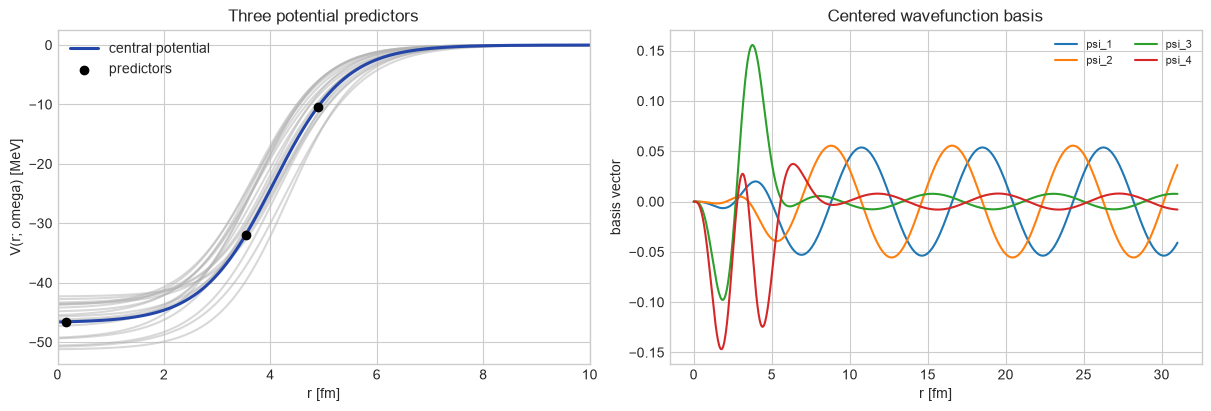

In [15]:
emulator_ws3 = ScatteringLROM(
    problem, BasisConfig(size=BASIS_SIZE), MaxVol(count=3),
).train(training_data_ws)
model_ws3 = emulator_ws3.channel_models[(0, 0.0)].learned
lrom_train_ws3 = np.asarray([
    emulator_ws3.predict(sample).wavefunction((0, 0.0))
    for sample in train_samples_ws
])
lrom_test_ws3 = np.asarray([
    emulator_ws3.predict(sample).wavefunction((0, 0.0))
    for sample in test_samples_ws
])
ls_train_coordinates_ws = model_ws3.basis.project(train_phi_ws)
ls_test_coordinates_ws = model_ws3.basis.project(test_phi_ws)
ls_train_ws = model_ws3.basis.reconstruct(ls_train_coordinates_ws)
ls_test_ws = model_ws3.basis.reconstruct(ls_test_coordinates_ws)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
predictor_r_ws3 = model_ws3.selected_coordinates / system.wave_number
for optical in train_physical_potential_ws[::4]:
    axes[0].plot(radius, optical.real, color="0.7", alpha=.5)
axes[0].plot(radius, potential0.real, color="#2446A8", lw=2.2, label="central potential")
axes[0].scatter(predictor_r_ws3, np.interp(predictor_r_ws3, radius, potential0.real), color="black", zorder=4, label="predictors")
axes[0].set(xlim=(0,10), xlabel="r [fm]", ylabel="V(r; omega) [MeV]", title="Three potential predictors")
axes[0].legend()
for index in range(BASIS_SIZE):
    axes[1].plot(radius, model_ws3.basis.vectors[:,index].real, label=f"psi_{index+1}")
axes[1].set(xlabel="r [fm]", ylabel="basis vector", title="Centered wavefunction basis")
axes[1].legend(ncol=2, fontsize=8)
plt.show()

## 2.2 ROSE benchmark and coefficient geometry

ROSE is trained independently on the same three-parameter rows. The
coefficient plots retain separate rows for LS, LROM, and ROSE. Smooth
curves show fixed-$a_v$ slices of the held-out coordinate manifold as
$V_v$ varies; curve color labels the chosen $R_v$. Open circles show the
training coefficients at their original three-dimensional parameter
locations. Coefficients from the ROSE basis remain distinct from the
$a_i$ coordinates of the centered LROM basis.

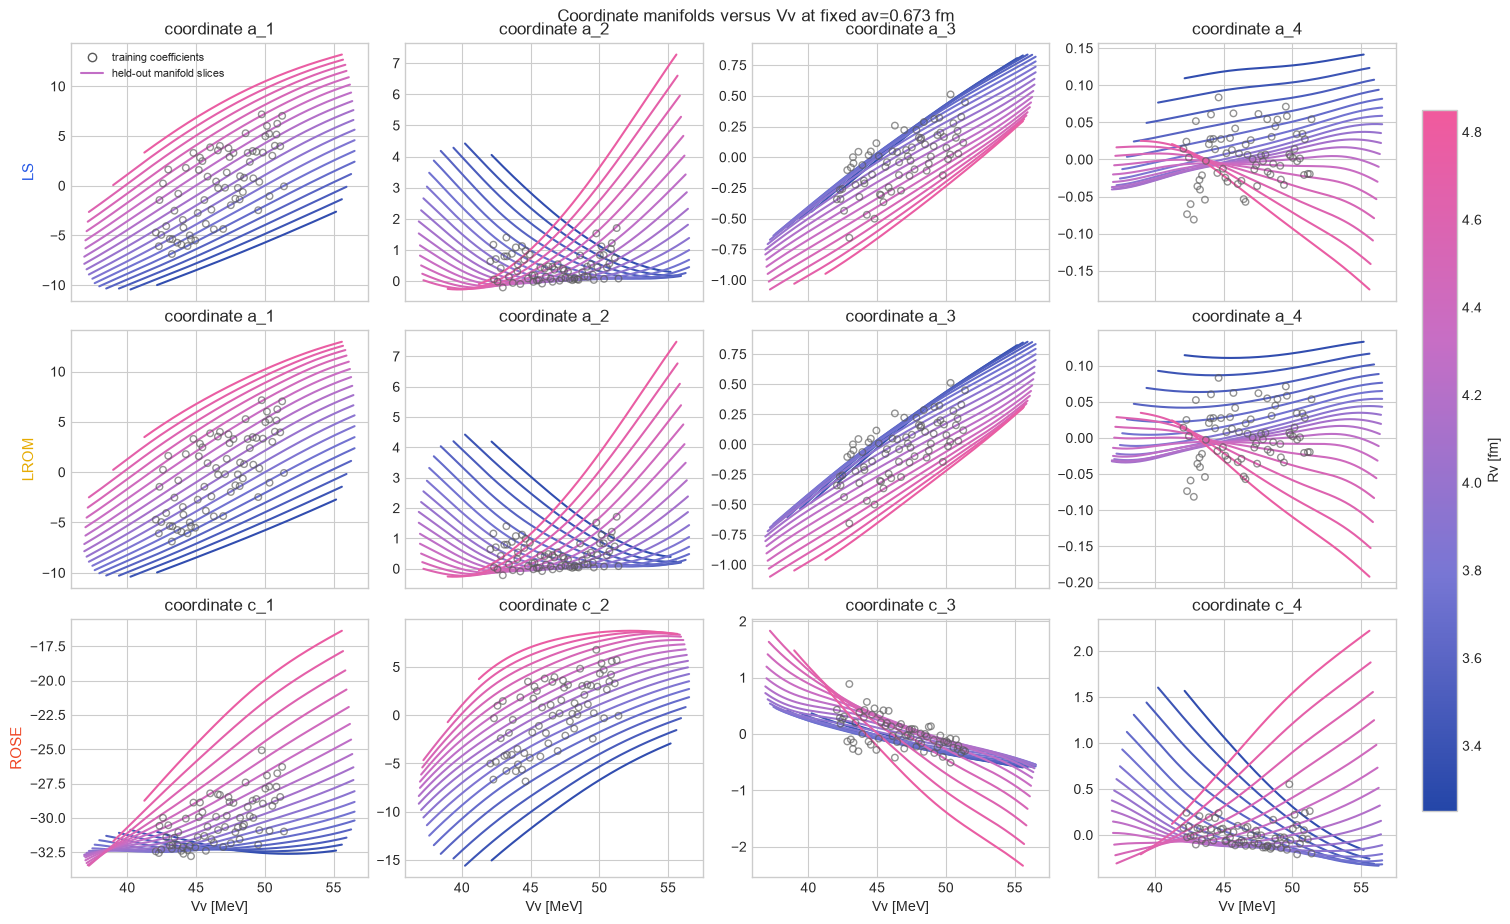

In [16]:
rose_ws = wavefunction_benchmark(
    radius, train_ws, test_ws,
    basis_size=BASIS_SIZE, eim_size=8,
)
coordinates_ws = {
    "LS": (ls_train_coordinates_ws, ls_test_coordinates_ws, "a", COLORS["LS"]),
    "LROM": (
        np.asarray([emulator_ws3.predict(s).coordinates((0,0.0)) for s in train_samples_ws]),
        np.asarray([emulator_ws3.predict(s).coordinates((0,0.0)) for s in test_samples_ws]),
        "a", COLORS["LROM"],
    ),
    "ROSE": (rose_ws.training_coefficients, rose_ws.testing_coefficients, "c", COLORS["ROSE"]),
}
from scipy.interpolate import LinearNDInterpolator, RBFInterpolator
from matplotlib.lines import Line2D

# Interpolate the held-out coordinates in the complete three-parameter
# space, then inspect one family of slices at the median diffuseness.
parameter_scale = np.maximum(test_ws.std(axis=0), 1.0e-12)
av_fixed = np.median(test_ws[:,2])
vv_grid = np.linspace(test_ws[:,0].min(), test_ws[:,0].max(), 240)
rv_slices = np.linspace(test_ws[:,1].min(), test_ws[:,1].max(), 20)
color_norm = plt.Normalize(rv_slices.min(), rv_slices.max())

fig, axes = plt.subplots(
    3, BASIS_SIZE, figsize=(15, 9), sharex=True,
    layout="constrained",
)
for row_index,(name,(training,testing,symbol,color)) in enumerate(coordinates_ws.items()):
    for column in range(BASIS_SIZE):
        ax = axes[row_index,column]
        values = testing[:,column].real
        smooth = RBFInterpolator(
            test_ws/parameter_scale, values,
            kernel="thin_plate_spline", smoothing=0.05,
        )
        convex_hull = LinearNDInterpolator(test_ws, values)
        for rv in rv_slices:
            query = np.column_stack([
                vv_grid,
                np.full_like(vv_grid,rv),
                np.full_like(vv_grid,av_fixed),
            ])
            inside = ~np.isnan(convex_hull(query))
            curve = np.full_like(vv_grid,np.nan)
            curve[inside] = smooth(query[inside]/parameter_scale)
            ax.plot(
                vv_grid,curve,
                color=PARAMETER_CMAP(color_norm(rv)),lw=1.5,
            )
        ax.scatter(
            train_ws[:,0],training[:,column].real,
            facecolors="none",edgecolors="0.35",s=22,alpha=.65,zorder=3,
        )
        ax.set_title(f"coordinate {symbol}_{column+1}")
        if column==0: ax.set_ylabel(name,color=color,fontsize=11)
        if row_index==2: ax.set_xlabel("Vv [MeV]")
legend_handles = [
    Line2D([0],[0],marker="o",linestyle="none",markerfacecolor="none",markeredgecolor="0.35",label="training coefficients"),
    Line2D([0],[0],color=PARAMETER_CMAP(.65),lw=1.5,label="held-out manifold slices"),
]
axes[0,0].legend(handles=legend_handles,fontsize=8)
scalar_map = plt.cm.ScalarMappable(norm=color_norm,cmap=PARAMETER_CMAP)
fig.colorbar(scalar_map,ax=axes,label="Rv [fm]",shrink=.84,pad=.02)
fig.suptitle(f"Coordinate manifolds versus Vv at fixed av={av_fixed:.3f} fm",y=1.01)
plt.show()

### Interpreting the open training points

The open circles are the actual training coordinates. Their horizontal
coordinate is the sampled $V_v$, and their vertical coordinate is the
corresponding LS, LROM, or ROSE reduced coefficient. No interpolation
or displacement is applied to these points.

The colored curves show a more restricted two-dimensional slice: every
curve fixes $a_v$ to the median testing value and fixes $R_v$ to the
value indicated by its color. In contrast, each training point retains
its independently sampled $(R_v,a_v)$. The open circles are therefore
expected to surround the fixed-$a_v$ curve family rather than lie
exactly on individual curves. A point outside the visible envelope can
reflect its different diffuseness and is not, by itself, evidence of an
inconsistent coefficient.

## 2.3 Held-out wavefunctions and error distributions

Test cases are ordered by their normalized distance from the central
optical potential. Three points spanning that distance are displayed.
Training and testing error distributions are then compared for LS,
LROM, and the independently evaluated ROSE RBM.

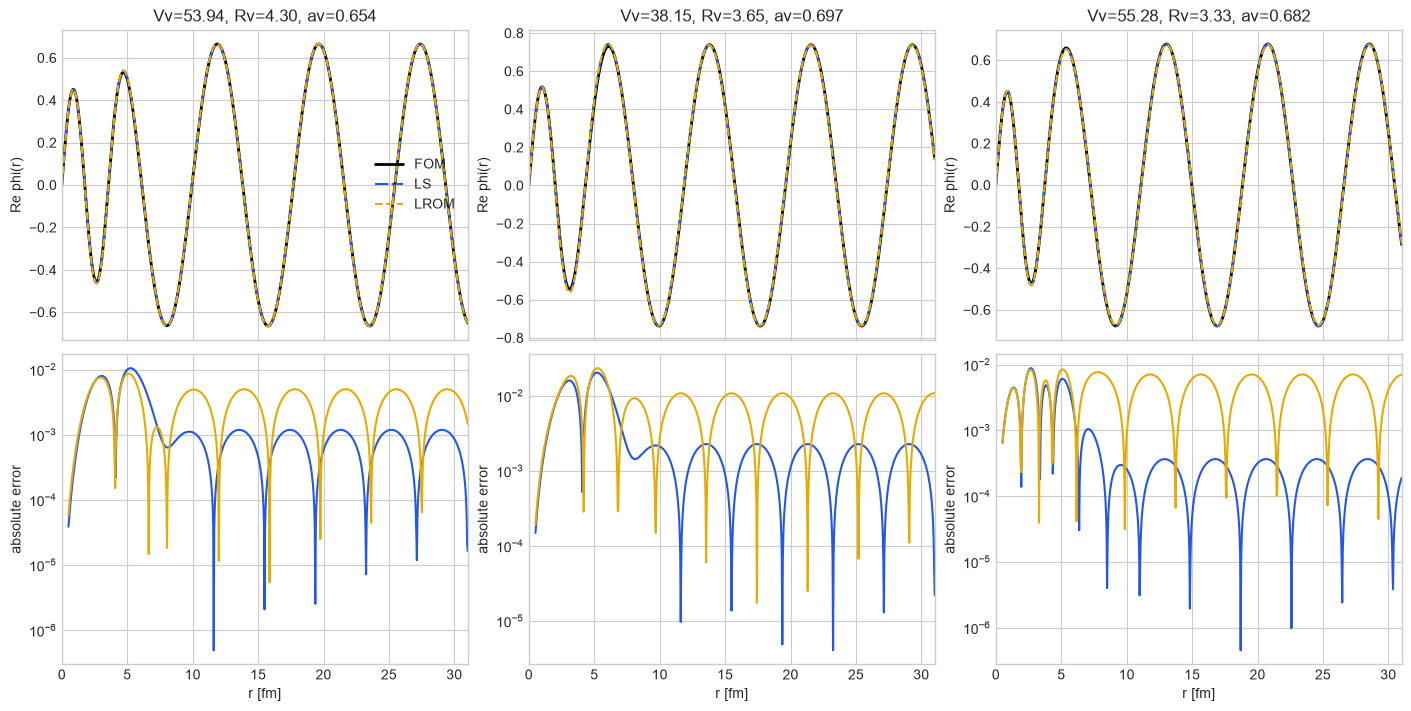

In [17]:
scaled_distance = np.linalg.norm((test_ws-omega0)/(np.array([.22,.20,.20])*omega0), axis=1)
ordered = np.argsort(scaled_distance)
selected_ws = ordered[[20,40,65]]
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex="col", layout="constrained")
for column,index in enumerate(selected_ws):
    axes[0,column].plot(radius,test_phi_ws[index].real,color="black",lw=2,label="FOM")
    axes[0,column].plot(radius,ls_test_ws[index].real,"-.",color=COLORS["LS"],label="LS")
    axes[0,column].plot(radius,lrom_test_ws3[index].real,"--",color=COLORS["LROM"],label="LROM")
    ls_error=np.abs(ls_test_ws[index]-test_phi_ws[index])
    lrom_error=np.abs(lrom_test_ws3[index]-test_phi_ws[index])
    axes[1,column].semilogy(radius[radial_error_mask],np.maximum(ls_error[radial_error_mask],ERROR_FLOOR),color=COLORS["LS"])
    axes[1,column].semilogy(radius[radial_error_mask],np.maximum(lrom_error[radial_error_mask],ERROR_FLOOR),color=COLORS["LROM"])
    axes[0,column].set(title=f"Vv={test_ws[index,0]:.2f}, Rv={test_ws[index,1]:.2f}, av={test_ws[index,2]:.3f}",ylabel="Re phi(r)")
    axes[1,column].set(xlabel="r [fm]",ylabel="absolute error",xlim=(0,radius[-1]))
axes[0,0].legend()
plt.show()

train_errors_ws3 = {
    "LS": relative_l2(ls_train_ws,train_phi_ws),
    "LROM": relative_l2(lrom_train_ws3,train_phi_ws),
    "ROSE": relative_l2(rose_ws.training_prediction,rose_ws.training_exact),
}
test_errors_ws3 = {
    "LS": relative_l2(ls_test_ws,test_phi_ws),
    "LROM": relative_l2(lrom_test_ws3,test_phi_ws),
    "ROSE": relative_l2(rose_ws.testing_prediction,rose_ws.testing_exact),
}

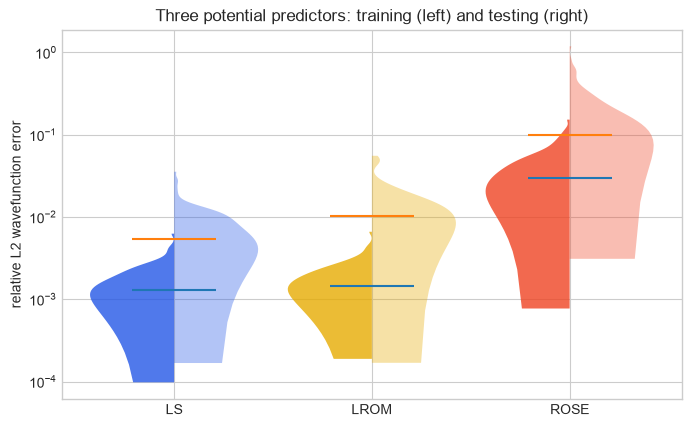

In [18]:
methods = ["LS","LROM","ROSE"]
positions = np.arange(1,4)
fig,ax=plt.subplots(figsize=(8,4.8))
left=ax.violinplot([train_errors_ws3[m] for m in methods],positions=positions,widths=.85,showmedians=True,showextrema=False)
right=ax.violinplot([test_errors_ws3[m] for m in methods],positions=positions,widths=.85,showmedians=True,showextrema=False)
for center,body,method in zip(positions,left["bodies"],methods):
    body.get_paths()[0].vertices[:,0]=np.minimum(body.get_paths()[0].vertices[:,0],center)
    body.set_facecolor(COLORS[method]); body.set_alpha(.8)
for center,body,method in zip(positions,right["bodies"],methods):
    body.get_paths()[0].vertices[:,0]=np.maximum(body.get_paths()[0].vertices[:,0],center)
    body.set_facecolor(COLORS[method]); body.set_alpha(.35)
ax.set_xticks(positions,methods); ax.set_yscale("log")
ax.set(ylabel="relative L2 wavefunction error",title="Three potential predictors: training (left) and testing (right)")
plt.show()

## 2.4 Increasing the potential feature count

The wavefunction basis remains fixed at $N_\phi=4$ while the potential
feature count increases from three to six. This isolates improvement in
the learned coordinate map from improvement in the wavefunction basis.
Both emulators are trained from the same `training_data_ws` object, so
the FOM wavefunctions and associated potential snapshots are generated
only once.

In [19]:
# Reuse exactly the same FOM database: only the learned feature count changes.
emulator_ws6 = ScatteringLROM(
    problem, BasisConfig(size=BASIS_SIZE), MaxVol(count=6),
).train(training_data_ws)
model_ws6 = emulator_ws6.channel_models[(0, 0.0)].learned
lrom_train_ws6 = np.asarray([
    emulator_ws6.predict(sample).wavefunction((0, 0.0))
    for sample in train_samples_ws
])
lrom_test_ws6 = np.asarray([
    emulator_ws6.predict(sample).wavefunction((0, 0.0))
    for sample in test_samples_ws
])
comparison_ws = pd.DataFrame({
    "model": ["best in four-dimensional basis", "LROM: 3 predictors", "LROM: 6 predictors", "ROSE RBM"],
    "testing reference": ["Numerov FOM", "Numerov FOM", "Numerov FOM", "ROSE FOM"],
    "median relative L2": [
        np.median(relative_l2(ls_test_ws,test_phi_ws)),
        np.median(relative_l2(lrom_test_ws3,test_phi_ws)),
        np.median(relative_l2(lrom_test_ws6,test_phi_ws)),
        np.median(relative_l2(rose_ws.testing_prediction,rose_ws.testing_exact)),
    ],
    "maximum relative L2": [
        np.max(relative_l2(ls_test_ws,test_phi_ws)),
        np.max(relative_l2(lrom_test_ws3,test_phi_ws)),
        np.max(relative_l2(lrom_test_ws6,test_phi_ws)),
        np.max(relative_l2(rose_ws.testing_prediction,rose_ws.testing_exact)),
    ],
})
comparison_ws

,model,testing reference,median relative L2,maximum relative L2
0,best in four-dimensional basis,Numerov FOM,0.005479,0.035489
1,LROM: 3 predictors,Numerov FOM,0.010359,0.055487
2,LROM: 6 predictors,Numerov FOM,0.005481,0.038813
3,ROSE RBM,ROSE FOM,0.098866,1.187895


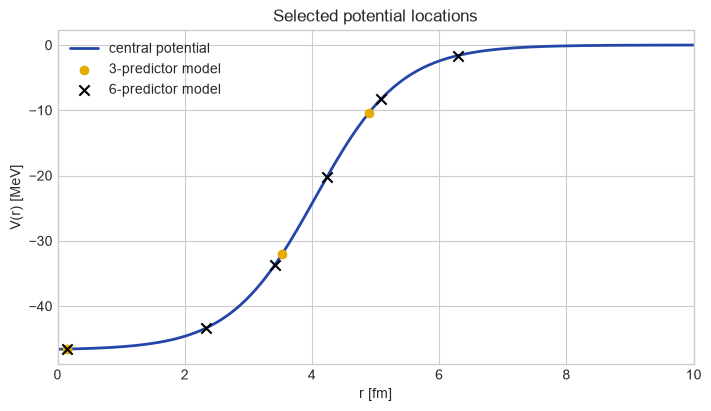

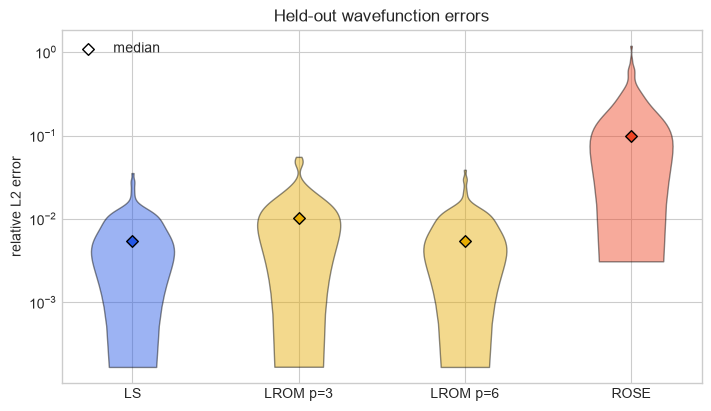

In [20]:
fig,ax=plt.subplots(figsize=(7,4),layout="constrained")
ax.plot(radius,potential0.real,color="#2446A8",lw=2,label="central potential")
predictor_r_ws3 = model_ws3.selected_coordinates/system.wave_number
predictor_r_ws6 = model_ws6.selected_coordinates/system.wave_number
ax.scatter(predictor_r_ws3,np.interp(predictor_r_ws3,radius,potential0.real),color=COLORS["LROM"],label="3-predictor model",zorder=4)
ax.scatter(predictor_r_ws6,np.interp(predictor_r_ws6,radius,potential0.real),marker="x",s=55,color="black",label="6-predictor model",zorder=5)
ax.set(xlim=(0,10),xlabel="r [fm]",ylabel="V(r) [MeV]",title="Selected potential locations")
ax.legend()
plt.show()

distributions=[
    relative_l2(ls_test_ws,test_phi_ws),
    relative_l2(lrom_test_ws3,test_phi_ws),
    relative_l2(lrom_test_ws6,test_phi_ws),
    relative_l2(rose_ws.testing_prediction,rose_ws.testing_exact),
]
labels=["LS","LROM p=3","LROM p=6","ROSE"]
method_colors=[COLORS["LS"],COLORS["LROM"],COLORS["LROM"],COLORS["ROSE"]]
fig,ax=plt.subplots(figsize=(7,4),layout="constrained")
violin=ax.violinplot(
    [np.maximum(values,1e-14) for values in distributions],
    showmedians=False,
    showextrema=False,
)
for position,(body,color,values) in enumerate(zip(violin["bodies"],method_colors,distributions),start=1):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(.45)
    ax.scatter(position,np.median(values),marker="D",s=35,color=color,edgecolor="black",zorder=5)
ax.set_yscale("log")
ax.set_xticks([1,2,3,4],labels)
ax.set(ylabel="relative L2 error",title="Held-out wavefunction errors")
ax.scatter([],[],marker="D",s=35,facecolor="white",edgecolor="black",label="median")
ax.legend()
plt.show()

<!-- RIDGE_AND_BACKEND_EXTENSION -->
# 3. Stability of the learned implicit equation

The preceding sections reproduce the original detailed wavefunction
study. We now add the lessons from the stability investigation without
changing the physics, snapshots, reduced bases, or predictor locations.

OLS minimizes the stacked implicit residual. Ridge instead minimizes

$$\|D\theta-t\|_2^2+\alpha\|\theta\|_2^2,\qquad
\alpha=\lambda\sigma_{\max}(D)^2.$$

Thus `ridge=1e-14` is relative to the scale of the design matrix. It
suppresses weakly identified, mutually cancelling coefficient
directions while leaving well-identified directions almost unchanged.

In [21]:
RIDGE = 1e-14

def implicit_design(learned, data, channel=(0, 0.0)):
    coordinates = learned.basis.project(data.wavefunctions[channel])
    features = learned.features(data.potentials[channel])
    blocks = np.concatenate([
        np.einsum("sf,si->sfi", features, coordinates, optimize=True),
        -features[..., None],
    ], axis=2)
    return blocks.reshape(len(features), features.shape[1]*(coordinates.shape[1]+1))

ridge_vv = ScatteringLROM(
    problem, BasisConfig(size=BASIS_SIZE), MaxVol(count=1, ridge=RIDGE)
).train(training_data_vv, precomputed_bases={(0,0.0): model_vv.basis})
ridge_vv_wave = np.asarray([
    ridge_vv.predict(row).wavefunction((0,0.0)) for row in test_samples_vv
])
ols_vv_wave = lrom_test_vv
ols_vv_condition = np.asarray([
    emulator_vv.predict(row).condition_number((0,0.0)) for row in test_samples_vv
])
ridge_vv_condition = np.asarray([
    ridge_vv.predict(row).condition_number((0,0.0)) for row in test_samples_vv
])

design_vv = implicit_design(model_vv, training_data_vv)
singular_vv = np.linalg.svd(design_vv, compute_uv=False)
pd.DataFrame({
    "fit": ["OLS", "ridge-14"],
    "median test relative L2": [
        np.median(relative_l2(ols_vv_wave, test_phi_vv)),
        np.median(relative_l2(ridge_vv_wave, test_phi_vv)),
    ],
    "maximum test relative L2": [
        np.max(relative_l2(ols_vv_wave, test_phi_vv)),
        np.max(relative_l2(ridge_vv_wave, test_phi_vv)),
    ],
    "maximum online condition": [ols_vv_condition.max(), ridge_vv_condition.max()],
})

,fit,median test relative L2,maximum test relative L2,maximum online condition
0,OLS,0.000008,0.000479,10.192208
1,ridge-14,0.000008,0.000479,10.191291


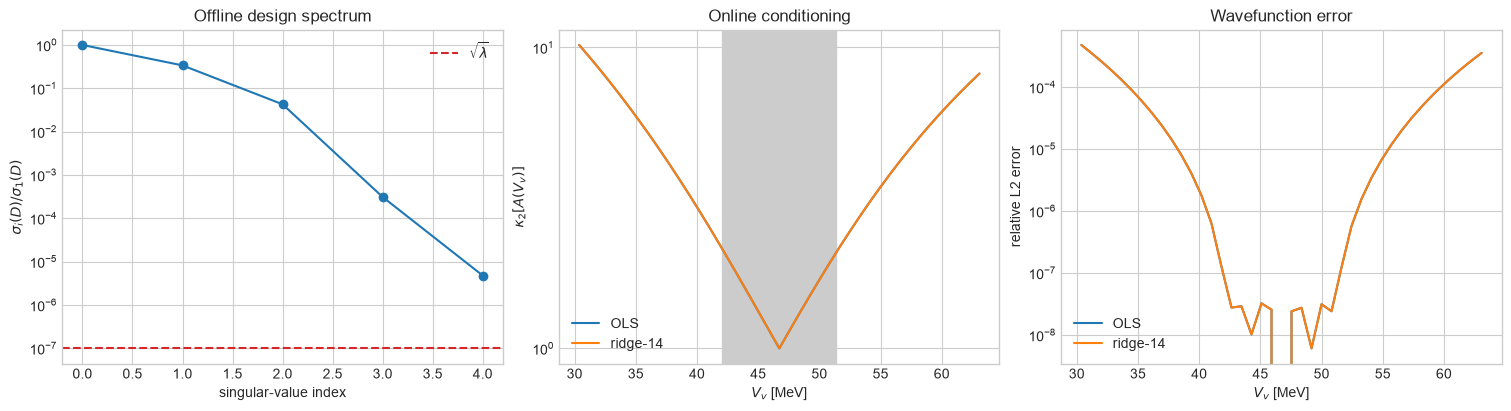

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15,4), layout="constrained")
axes[0].semilogy(singular_vv/singular_vv[0], "o-")
axes[0].axhline(np.sqrt(RIDGE), color="tab:red", ls="--", label=r"$\sqrt{\lambda}$")
axes[0].set(xlabel="singular-value index", ylabel=r"$\sigma_i(D)/\sigma_1(D)$", title="Offline design spectrum")
axes[0].legend()
axes[1].semilogy(test_vv[:,0], ols_vv_condition, label="OLS")
axes[1].semilogy(test_vv[:,0], ridge_vv_condition, label="ridge-14")
axes[1].axvspan(train_vv[:,0].min(), train_vv[:,0].max(), color="0.8")
axes[1].set(xlabel=r"$V_v$ [MeV]", ylabel=r"$\kappa_2[A(V_v)]$", title="Online conditioning")
axes[1].legend()
axes[2].semilogy(test_vv[:,0], relative_l2(ols_vv_wave,test_phi_vv), label="OLS")
axes[2].semilogy(test_vv[:,0], relative_l2(ridge_vv_wave,test_phi_vv), label="ridge-14")
axes[2].set(xlabel=r"$V_v$ [MeV]", ylabel="relative L2 error", title="Wavefunction error")
axes[2].legend()
plt.show()

## 3.1 Three-parameter ridge comparison

We repeat the comparison for the $(V_v,R_v,a_v)$ design. The ridge fit
reuses the OLS reduced basis and selected predictor coordinates, so any
change comes only from how the implicit equation coefficients are fit.

In [23]:
ridge_ws3 = ScatteringLROM(
    problem, BasisConfig(size=BASIS_SIZE), MaxVol(count=3, ridge=RIDGE)
).train(training_data_ws, precomputed_bases={(0,0.0): model_ws3.basis})
ridge_test_ws = np.asarray([
    ridge_ws3.predict(row).wavefunction((0,0.0)) for row in test_samples_ws
])
ols_condition_ws = np.asarray([
    emulator_ws3.predict(row).condition_number((0,0.0)) for row in test_samples_ws
])
ridge_condition_ws = np.asarray([
    ridge_ws3.predict(row).condition_number((0,0.0)) for row in test_samples_ws
])
pd.DataFrame({
    "fit":["OLS","ridge-14"],
    "median relative L2":[np.median(relative_l2(lrom_test_ws3,test_phi_ws)),np.median(relative_l2(ridge_test_ws,test_phi_ws))],
    "95% relative L2":[np.quantile(relative_l2(lrom_test_ws3,test_phi_ws),.95),np.quantile(relative_l2(ridge_test_ws,test_phi_ws),.95)],
    "worst condition":[ols_condition_ws.max(),ridge_condition_ws.max()],
    "coefficient norm":[
        np.linalg.norm(np.r_[model_ws3.matrices.ravel(),model_ws3.vectors.ravel()]),
        np.linalg.norm(np.r_[ridge_ws3.channel_models[(0,0.0)].learned.matrices.ravel(),ridge_ws3.channel_models[(0,0.0)].learned.vectors.ravel()]),
    ],
})

,fit,median relative L2,95% relative L2,worst condition,coefficient norm
0,OLS,0.010359,0.044913,155.968861,3.729072
1,ridge-14,0.010359,0.044913,155.968810,3.729072


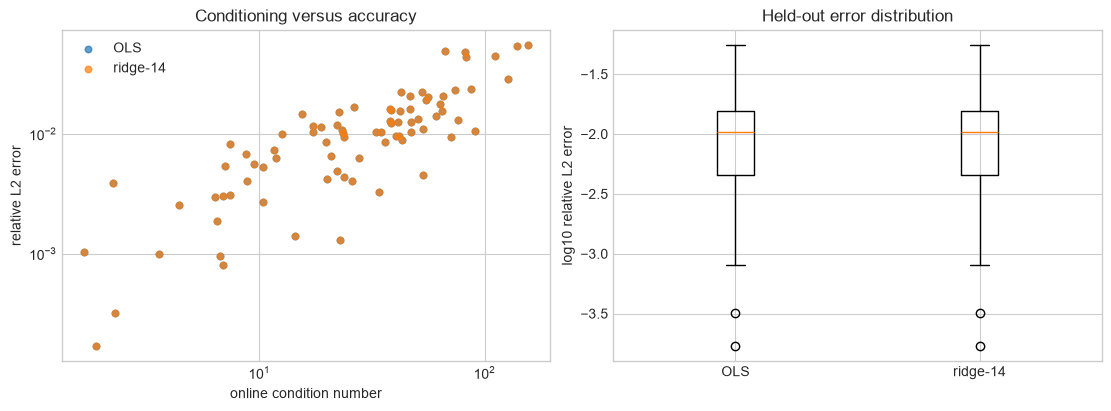

In [24]:
fig, axes = plt.subplots(1,2,figsize=(11,4),layout="constrained")
axes[0].scatter(ols_condition_ws, relative_l2(lrom_test_ws3,test_phi_ws), s=22, alpha=.7, label="OLS")
axes[0].scatter(ridge_condition_ws, relative_l2(ridge_test_ws,test_phi_ws), s=22, alpha=.7, label="ridge-14")
axes[0].set(xscale="log",yscale="log",xlabel="online condition number",ylabel="relative L2 error",title="Conditioning versus accuracy")
axes[0].legend()
axes[1].boxplot([np.log10(relative_l2(lrom_test_ws3,test_phi_ws)),np.log10(relative_l2(ridge_test_ws,test_phi_ws))],tick_labels=["OLS","ridge-14"])
axes[1].set(ylabel="log10 relative L2 error",title="Held-out error distribution")
plt.show()

## 3.2 Compiled batched online solve

`LROM_BACKEND=cpu` uses NumPy. `LROM_BACKEND=gpu` uses a JIT-compiled
JAX solve on a visible GPU; `auto` selects a GPU when available. Only
the batched reduced systems move to the accelerator—the fitted equation,
feature construction, S-matrix formula, and observable remain identical.

In [25]:
angles_backend = np.linspace(1,179,90)
cpu_runtime = get_runtime("cpu")
ridge_ws3.repack("padded")
# Warm up NumPy/JAX and then time a whole held-out batch.
ridge_ws3.cross_sections(test_samples_ws,angles_backend,linear_solver=runtime.solve)
rows=[]
for label,engine in [("NumPy CPU",cpu_runtime),(runtime.name,runtime)]:
    elapsed=[]
    for _ in range(8):
        tic=time.perf_counter()
        values=ridge_ws3.cross_sections(test_samples_ws,angles_backend,linear_solver=engine.solve)
        elapsed.append(time.perf_counter()-tic)
    rows.append({"runtime":label,"device":engine.device,"batch cases":len(test_samples_ws),"best milliseconds":1000*min(elapsed),"cases/second":len(test_samples_ws)/min(elapsed)})
pd.DataFrame(rows)

,runtime,device,batch cases,best milliseconds,cases/second
0,NumPy CPU,CPU,81,0.7892,102635.586088
1,numpy-cpu,CPU,81,0.7837,103355.887330


# Summary

The calculations separate three sources of approximation:

- the LS result measures truncation of the centered wavefunction basis;
- the LROM–LS gap measures the learned implicit coordinate map;
- the ROSE result provides an independent Petrov–Galerkin benchmark with
  its own FOM and free-reference basis.

The same modular components extend directly to multiple partial waves.
The next notebook assembles the channel S matrices into elastic
differential cross sections for the full complex optical potential.